In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalNum1: int
    finalNum2: int

In [3]:
graph = StateGraph(AgentState)

In [4]:
def add_action(state: AgentState):
    """ excute addtion operation by num1 and num2 """
    state["finalNum1"] = state["number1"] + state["number2"]
    return state

def substract_action(state: AgentState):
    """ excute substraction operation by num1 and num2 """
    state["finalNum1"] = state["number1"] - state["number2"]
    return state

def add_action2(state: AgentState):
    """ excute addtion operation by num3 and num4 """
    state["finalNum2"] = state["number3"] + state["number4"]
    return state

def substract_action2(state: AgentState):
    """ excute substraction operation by num3 and num4 """
    state["finalNum2"] = state["number3"] - state["number4"]
    return state

def route_condition_action(state: AgentState):
    if state["operation1"] == "+":
        return "add_operation"
    elif state["operation1"] == "-":
        return "substract_operation"

def route_condition_action2(state: AgentState):
    if state["operation2"] == "+":
        return "add_operation2"
    elif state["operation2"] == "-":
        return "substract_operation2"

In [5]:
# add Node
graph.add_node("add_node", add_action)
graph.add_node("substract_node", substract_action)
graph.add_node("add_node2", add_action2)
graph.add_node("substract_node2", substract_action2)
graph.add_node("route",lambda state: state)
graph.add_node("route2",lambda state: state)

## add Edges
graph.add_edge(START,"route")
graph.add_conditional_edges(
    "route",
    route_condition_action,
    {
        "add_operation": "add_node",
        "substract_operation": "substract_node",
    }
)
graph.add_edge("add_node","route2")
graph.add_edge("substract_node","route2")
graph.add_conditional_edges(
    "route2",
    route_condition_action2,
    {
        # Edge : Node
        "add_operation2": "add_node2",
        "substract_operation2": "substract_node2",
    }
)
graph.add_edge("add_node2",END)
graph.add_edge("substract_node2",END)

app = graph.compile()

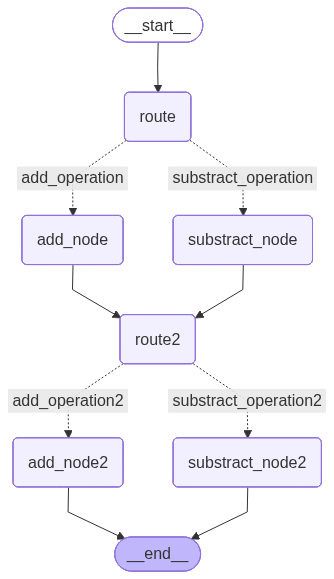

In [6]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
print(app.invoke(AgentState(number1=1,number2=5,operation1="+",operation2="-",number3=3,number4=8)))

{'number1': 1, 'operation1': '+', 'number2': 5, 'number3': 3, 'operation2': '-', 'number4': 8, 'finalNum1': 6, 'finalNum2': -5}
